In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from monodromy.coverage import gates_to_coverage
from monodromy.haar import expected_cost, gates_to_haar
from monodromy.render import gates_to_coverage_plot
from qiskit import QuantumCircuit
from qiskit.circuit.library import CZGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator
from qutip import Qobj
from tqdm import tqdm
from weylchamber import WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive

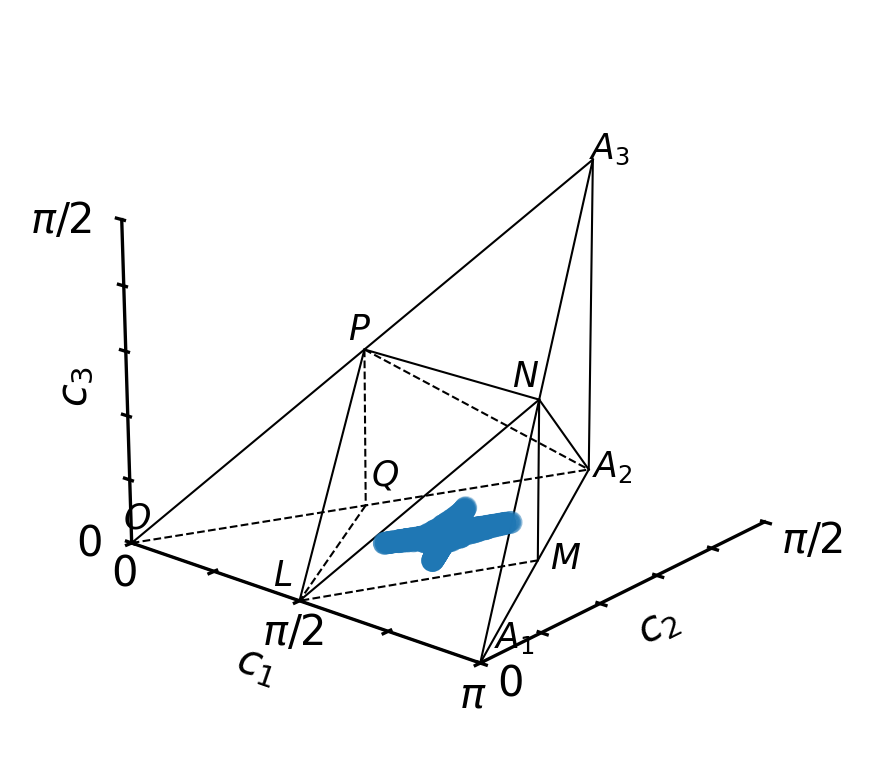

In [2]:
from numpy.random import uniform

x_targ = np.pi**2 / 5
z_targ = 0
x_eps = 0.25  # idk, up to 25% error
z_eps = 0.25  # idk
rand_pd_basis_gate = lambda: ZZ_ParallelDrive(
    g_zz=3 * np.pi / 4,
    g_ix=uniform((1 + x_eps) * x_targ, (1 - x_eps) * x_targ),
    g_xi=uniform((1 + x_eps) * x_targ, (1 - x_eps) * x_targ),
    g_zi=uniform((1 + z_eps) * z_targ, (1 - z_eps) * z_targ),
    g_iz=uniform((1 + z_eps) * z_targ, (1 - z_eps) * z_targ),
).to_unitary()

w = WeylChamber()
for _ in range(N := 1_000):
    w.add_point(*c1c2c3(rand_pd_basis_gate()))
w.plot()

In [3]:
ISA_N = 2


def b_like_gate(x_eps=0.25, z_eps=0.25):
    x_targ = np.pi**2 / 5
    z_targ = 0
    return ZZ_ParallelDrive(
        g_zz=3 * np.pi / 4,
        g_ix=uniform((1 + x_eps) * x_targ, (1 - x_eps) * x_targ),
        g_xi=uniform((1 + x_eps) * x_targ, (1 - x_eps) * x_targ),
        g_zi=uniform((1 + z_eps) * z_targ, (1 - z_eps) * z_targ),
        g_iz=uniform((1 + z_eps) * z_targ, (1 - z_eps) * z_targ),
    ).to_unitary()


isa = [b_like_gate() for _ in range(ISA_N)]
# monodromy requires each gate have unique string identifier
for idx, gate in enumerate(isa):
    gate.name = f"gate.name{idx}"

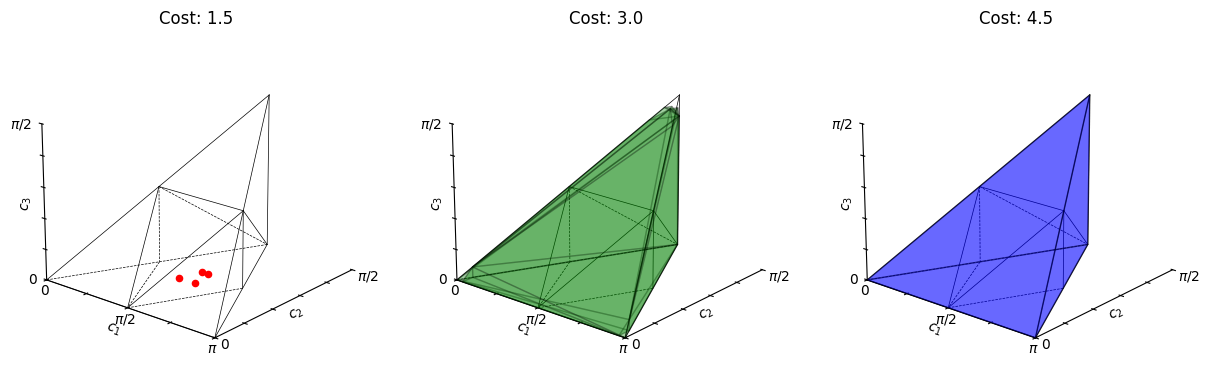

3.000000002302757

In [4]:
coverage = gates_to_coverage_plot(
    *isa,
    costs=[1.5] * ISA_N,
    single_qubit_cost=0,
)
expected_cost(coverage)

In [43]:
def simple_cost(frac):
    coverage_set = gates_to_coverage(
        iSwapGate().power(frac),
        costs=[1],
        single_qubit_cost=0,
    )
    expected_num = expected_cost(coverage_set)
    return expected_num
    # return expected_num * (frac + single_q) + single_q


frac = np.geomspace(1, 1 / 16, 32)
single_q_costs = [0, 0.1, 0.25, 0.5]
basic_costs = [simple_cost(f) for f in tqdm(frac)]  # expensive part


def adjust(single_q):
    return basic_costs * (frac + single_q) + single_q


adjusted_costs = [adjust(single_q) for single_q in single_q_costs]
for single_q, adjusted_cost in zip(single_q_costs, adjusted_costs):
    plt.plot(
        frac,
        adjusted_cost,
        marker=".",
        label=f"c(1q)={single_q}",
    )

    min_index = np.argmin(adjusted_cost)
    min_value = adjusted_cost[min_index]
    min_frac = frac[min_index]
    print(
        f"min expected cost for c(1q)={single_q}: {min_value:.4f} at frac={min_frac:.4f}"
    )

plt.xlabel("frac")
plt.ylabel("expected_cost")
plt.legend()
plt.show()

 59%|█████▉    | 19/32 [02:10<01:39,  7.63s/it]

KeyboardInterrupt: 